In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [92]:
factories_df = pd.read_csv("./data/US Candy Distributors/Candy_Factories.csv")
products_df = pd.read_csv("./data/US Candy Distributors/Candy_Products.csv")
sales_df = pd.read_csv("./data/US Candy Distributors/Candy_Sales.csv", parse_dates=["Ship Date", "Order Date"])
targets_df = pd.read_csv("./data/US Candy Distributors/Candy_Targets.csv")
uszips_df = pd.read_csv("./data/US Candy Distributors/uszips.csv", dtype={"zip": str})

In [93]:
candy_sales_dfs = {
    "Candy Factories": factories_df,
    "Candy Products": products_df,
    "Candy Sales": sales_df,
    "Candy Tragets": targets_df,
    "US zips": uszips_df
}

for name, df in candy_sales_dfs.items():
    print("=" * 20)
    print(name)
    print("=" * 20)

    print(df.dtypes)
    print("No. of rows:", df.shape[0])
    print("")
    print(df.head(2))
    print("")
    print("*" * 100)
    print("")


Candy Factories
Factory          str
Latitude     float64
Longitude    float64
dtype: object
No. of rows: 5

           Factory   Latitude   Longitude
0    Lot's O' Nuts  32.881893 -111.768036
1  Wicked Choccy's  32.076176  -81.088371

****************************************************************************************************

Candy Products
Division            str
Product Name        str
Factory             str
Product ID          str
Unit Price      float64
Unit Cost       float64
dtype: object
No. of rows: 15

    Division                       Product Name        Factory     Product ID  \
0  Chocolate  Wonka Bar - Nutty Crunch Surprise  Lot's O' Nuts  CHO-NUT-13000   
1  Chocolate          Wonka Bar - Fudge Mallows  Lot's O' Nuts  CHO-FUD-51000   

   Unit Price  Unit Cost  
0        3.49        1.0  
1        3.60        1.2  

****************************************************************************************************

Candy Sales
Row ID                     int64

## Columns rename

In [94]:
def rename_columns(df):
    return [col.lower().replace(" ", "_").replace("/", "_") for col in df.columns]

for df in candy_sales_dfs.values():
    df.columns = rename_columns(df)

## apply()

In [95]:
sales_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28


### Calculate the Gross Profit %

```
Gross Profit % = (Sales - Cost) / Cost
```

In [96]:
round((sales_df["sales"] - sales_df["cost"]) / sales_df["cost"] * 100, 2)

0        188.46
1        227.27
2        200.00
3        185.09
4        185.09
          ...  
10189    227.27
10190    249.00
10191    188.46
10192    188.46
10193    200.00
Length: 10194, dtype: float64

In [97]:
sales_df.apply(lambda row: (row["sales"] - row["cost"]) / row["cost"] * 100, axis=1)

0        188.461538
1        227.272727
2        200.000000
3        185.087719
4        185.087719
            ...    
10189    227.272727
10190    249.000000
10191    188.461538
10192    188.461538
10193    200.000000
Length: 10194, dtype: float64

In [98]:
def calc_gross_profit(row):
    sales = row["sales"]
    cost = row["cost"]

    gross_profit = (sales - cost) / cost * 100
    return round(gross_profit, 2)

sales_df.apply(calc_gross_profit, axis=1)

0        188.46
1        227.27
2        200.00
3        185.09
4        185.09
          ...  
10189    227.27
10190    249.00
10191    188.46
10192    188.46
10193    200.00
Length: 10194, dtype: float64

In [99]:
sales_df["gross_profit_percent"] = sales_df.apply(calc_gross_profit, axis=1)

In [100]:
sales_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost,gross_profit_percent
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,188.46
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20,227.27
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40,200.00
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,185.09
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,185.09


In [101]:
df_1 = sales_df[["sales", "units", "cost", "gross_profit"]]

df_1.apply(sum, axis=0)

sales           141783.63
units            38654.00
cost             48340.83
gross_profit     93442.80
dtype: float64

In [102]:
df_1.head()

,sales,units,cost,gross_profit
0,7.50,2,2.60,4.90
1,7.20,2,2.20,5.00
2,7.20,2,2.40,4.80
3,9.75,3,3.42,6.33
4,6.50,2,2.28,4.22


In [103]:
df_1["sales"] + df_1["units"] + df_1["cost"] + df_1["gross_profit"]

0        17.0
1        16.4
2        16.4
3        22.5
4        15.0
         ... 
10189    32.8
10190    39.9
10191    17.0
10192    42.5
10193    24.6
Length: 10194, dtype: float64

### Question: Find the month over month growth %

In [104]:
sales_df["order_year"] = sales_df["order_date"].dt.year
sales_df["order_month"] = sales_df["order_date"].dt.month

sales_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,region,product_id,product_name,sales,units,gross_profit,cost,gross_profit_percent,order_year,order_month
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,188.46,2021,3
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20,227.27,2021,3
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40,200.00,2021,9
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,185.09,2021,9
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,...,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,185.09,2022,10


In [105]:
monthly_sales_df = sales_df.groupby(["order_year", "order_month"]).agg(total_sales=("sales", "sum"))
monthly_sales_df.head(15)

total_sales
order_year order_month             
2021       1                1065.24
           2                 547.09
           3                2245.63
           4                2058.97
           5                1855.21
           6                1838.43
           7                1908.23
           8                2258.46
           9                3927.08
           10               2544.88
           11               4357.18
           12               4347.15
2022       1                1028.66
           2                 832.78
           3                1893.27

In [106]:
prev_month_sales_df = monthly_sales_df.groupby(["order_year"]).shift(1).rename(columns={"total_sales": "prev_month_sales"})
prev_month_sales_df.head()

prev_month_sales
order_year order_month                  
2021       1                         NaN
           2                     1065.24
           3                      547.09
           4                     2245.63
           5                     2058.97

In [107]:
monthly_sales_joined_df = monthly_sales_df.join(prev_month_sales_df)
monthly_sales_joined_df.head()

total_sales  prev_month_sales
order_year order_month                               
2021       1                1065.24               NaN
           2                 547.09           1065.24
           3                2245.63            547.09
           4                2058.97           2245.63
           5                1855.21           2058.97

In [108]:
def mom_growth(row):
    current_month_sales = row["total_sales"]
    previous_month_sales = row["prev_month_sales"]

    growth = (current_month_sales - previous_month_sales) / previous_month_sales * 100

    return round(growth, 2)

monthly_sales_joined_df["MoM_growth"] = monthly_sales_joined_df.apply(mom_growth, axis=1)
monthly_sales_joined_df.head()

total_sales  prev_month_sales  MoM_growth
order_year order_month                                           
2021       1                1065.24               NaN         NaN
           2                 547.09           1065.24      -48.64
           3                2245.63            547.09      310.47
           4                2058.97           2245.63       -8.31
           5                1855.21           2058.97       -9.90

<Axes: xlabel='order_year,order_month'>

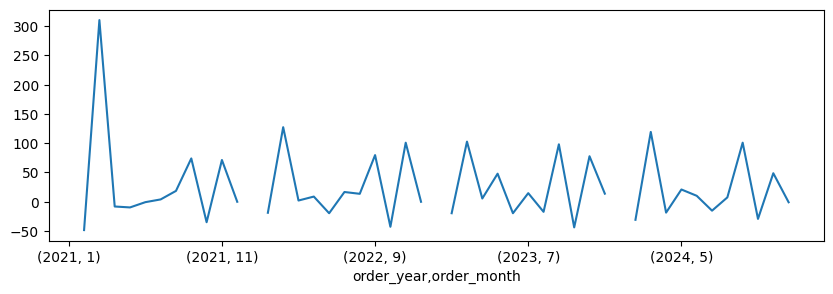

In [109]:
monthly_sales_joined_df["MoM_growth"].plot(figsize=(10, 3))

## transform()

In [110]:
df_1.head()

,sales,units,cost,gross_profit
0,7.50,2,2.60,4.90
1,7.20,2,2.20,5.00
2,7.20,2,2.40,4.80
3,9.75,3,3.42,6.33
4,6.50,2,2.28,4.22


In [111]:
df_1.shape

(10194, 4)

In [112]:
df_1.apply(sum)

sales           141783.63
units            38654.00
cost             48340.83
gross_profit     93442.80
dtype: float64

In [113]:
df_1["sales"].transform(lambda x: x * 100)

0         750.0
1         720.0
2         720.0
3         975.0
4         650.0
          ...  
10189    1440.0
10190    1745.0
10191     750.0
10192    1875.0
10193    1080.0
Name: sales, Length: 10194, dtype: float64

In [114]:
df_1["sales"].apply(lambda x: x * 100)

0         750.0
1         720.0
2         720.0
3         975.0
4         650.0
          ...  
10189    1440.0
10190    1745.0
10191     750.0
10192    1875.0
10193    1080.0
Name: sales, Length: 10194, dtype: float64

In [115]:
df_1.apply(lambda x: x * 100)

,sales,units,cost,gross_profit
0,750.0,200,260.0,490.0
1,720.0,200,220.0,500.0
2,720.0,200,240.0,480.0
3,975.0,300,342.0,633.0
4,650.0,200,228.0,422.0
...,...,...,...,...
10189,1440.0,400,440.0,1000.0
10190,1745.0,500,500.0,1245.0
10191,750.0,200,260.0,490.0
10192,1875.0,500,650.0,1225.0


In [116]:
df_1.transform(lambda x: x * 100)

,sales,units,cost,gross_profit
0,750.0,200,260.0,490.0
1,720.0,200,220.0,500.0
2,720.0,200,240.0,480.0
3,975.0,300,342.0,633.0
4,650.0,200,228.0,422.0
...,...,...,...,...
10189,1440.0,400,440.0,1000.0
10190,1745.0,500,500.0,1245.0
10191,750.0,200,260.0,490.0
10192,1875.0,500,650.0,1225.0


In [117]:
sales_df.groupby("order_year")["sales"].sum()

order_year
2021    28953.55
2022    29002.65
2023    36859.32
2024    46968.11
Name: sales, dtype: float64

In [118]:
sales_df["sales"].shape

(10194,)

In [119]:
sales_df.groupby("order_year")["sales"].transform(sum)

0        28953.55
1        28953.55
2        28953.55
3        28953.55
4        29002.65
           ...   
10189    36859.32
10190    36859.32
10191    36859.32
10192    36859.32
10193    46968.11
Name: sales, Length: 10194, dtype: float64

### Question: Find the percentage total for each month of the year

In [120]:
monthly_sales_df.head()

total_sales
order_year order_month             
2021       1                1065.24
           2                 547.09
           3                2245.63
           4                2058.97
           5                1855.21

In [121]:
total_sales_by_year = monthly_sales_df.groupby("order_year")["total_sales"].transform(sum)
total_sales_by_year

order_year  order_month
2021        1              28953.55
            2              28953.55
            3              28953.55
            4              28953.55
            5              28953.55
            6              28953.55
            7              28953.55
            8              28953.55
            9              28953.55
            10             28953.55
            11             28953.55
            12             28953.55
2022        1              29002.65
            2              29002.65
            3              29002.65
            4              29002.65
            5              29002.65
            6              29002.65
            7              29002.65
            8              29002.65
            9              29002.65
            10             29002.65
            11             29002.65
            12             29002.65
2023        1              36859.32
            2              36859.32
            3              36859.32
    

In [122]:
sales_merged_df = pd.merge(monthly_sales_df, total_sales_by_year, left_index=True, right_index=True)
sales_merged_df.columns = ["total_sales", "total_yearly_sales"]
sales_merged_df.head()

total_sales  total_yearly_sales
order_year order_month                                 
2021       1                1065.24            28953.55
           2                 547.09            28953.55
           3                2245.63            28953.55
           4                2058.97            28953.55
           5                1855.21            28953.55

In [123]:
monthly_sales_df["total_yearly_sales_2"] = monthly_sales_df.groupby("order_year")["total_sales"].transform(sum)
monthly_sales_df.head()

total_sales  total_yearly_sales_2
order_year order_month                                   
2021       1                1065.24              28953.55
           2                 547.09              28953.55
           3                2245.63              28953.55
           4                2058.97              28953.55
           5                1855.21              28953.55

In [124]:
def pct_total(row):
    x, y = row["total_sales"], row["total_yearly_sales"]

    return round(x / y * 100, 2)

sales_merged_df["percentage_total"] = sales_merged_df.apply(pct_total, axis=1)
sales_merged_df

total_sales  total_yearly_sales  percentage_total
order_year order_month                                                   
2021       1                1065.24            28953.55              3.68
           2                 547.09            28953.55              1.89
           3                2245.63            28953.55              7.76
           4                2058.97            28953.55              7.11
           5                1855.21            28953.55              6.41
           6                1838.43            28953.55              6.35
           7                1908.23            28953.55              6.59
           8                2258.46            28953.55              7.80
           9                3927.08            28953.55             13.56
           10               2544.88            28953.55              8.79
           11               4357.18            28953.55             15.05
           12               4347.15            28953.55             15.01
2022       1                1028.66            29002.65              3.55
           2                 832.78            29002.65              2.87
           3                1893.27            29002.65              6.53
           4                1929.25            29002.65              6.65
           5                2096.31            29002.65              7.23
           6                1680.33            29002.65              5.79
           7                1957.15            29002.65              6.75
           8                2219.19            29002.65              7.65
           9                3985.02            29002.65             13.74
           10               2271.10            29002.65              7.83
           11               4560.53            29002.65             15.72
           12               4549.06            29002.65             15.68
2023       1                1319.68            36859.32              3.58
           2                1058.31            36859.32              2.87
           3                2144.68            36859.32              5.82
           4                2259.44            36859.32              6.13
           5                3339.63            36859.32              9.06
           6                2677.83            36859.32              7.27
           7                3066.28            36859.32              8.32
           8                2531.73            36859.32              6.87
           9                5014.08            36859.32             13.60
           10               2804.08            36859.32              7.61
           11               4981.22            36859.32             13.51
           12               5662.36            36859.32             15.36
2024       1                2169.42            46968.11              4.62
           2                1495.34            46968.11              3.18
           3                3278.56            46968.11              6.98
           4                2663.00            46968.11              5.67
           5                3216.05            46968.11              6.85
           6                3537.10            46968.11              7.53
           7                2991.39            46968.11              6.37
           8                3208.37            46968.11              6.83
           9                6443.52            46968.11             13.72
           10               4541.81            46968.11              9.67
           11               6747.64            46968.11             14.37
           12               6675.91            46968.11             14.21

## Handling null values

In [127]:
monthly_sales_joined_df.fillna(0)

total_sales  prev_month_sales  MoM_growth
order_year order_month                                           
2021       1                1065.24              0.00        0.00
           2                 547.09           1065.24      -48.64
           3                2245.63            547.09      310.47
           4                2058.97           2245.63       -8.31
           5                1855.21           2058.97       -9.90
           6                1838.43           1855.21       -0.90
           7                1908.23           1838.43        3.80
           8                2258.46           1908.23       18.35
           9                3927.08           2258.46       73.88
           10               2544.88           3927.08      -35.20
           11               4357.18           2544.88       71.21
           12               4347.15           4357.18       -0.23
2022       1                1028.66              0.00        0.00
           2                 832.78           1028.66      -19.04
           3                1893.27            832.78      127.34
           4                1929.25           1893.27        1.90
           5                2096.31           1929.25        8.66
           6                1680.33           2096.31      -19.84
           7                1957.15           1680.33       16.47
           8                2219.19           1957.15       13.39
           9                3985.02           2219.19       79.57
           10               2271.10           3985.02      -43.01
           11               4560.53           2271.10      100.81
           12               4549.06           4560.53       -0.25
2023       1                1319.68              0.00        0.00
           2                1058.31           1319.68      -19.81
           3                2144.68           1058.31      102.65
           4                2259.44           2144.68        5.35
           5                3339.63           2259.44       47.81
           6                2677.83           3339.63      -19.82
           7                3066.28           2677.83       14.51
           8                2531.73           3066.28      -17.43
           9                5014.08           2531.73       98.05
           10               2804.08           5014.08      -44.08
           11               4981.22           2804.08       77.64
           12               5662.36           4981.22       13.67
2024       1                2169.42              0.00        0.00
           2                1495.34           2169.42      -31.07
           3                3278.56           1495.34      119.25
           4                2663.00           3278.56      -18.78
           5                3216.05           2663.00       20.77
           6                3537.10           3216.05        9.98
           7                2991.39           3537.10      -15.43
           8                3208.37           2991.39        7.25
           9                6443.52           3208.37      100.83
           10               4541.81           6443.52      -29.51
           11               6747.64           4541.81       48.57
           12               6675.91           6747.64       -1.06

In [129]:
monthly_sales_joined_df["MoM_growth"] = monthly_sales_joined_df["MoM_growth"].fillna(0)
monthly_sales_joined_df

total_sales  prev_month_sales  MoM_growth
order_year order_month                                           
2021       1                1065.24               NaN        0.00
           2                 547.09           1065.24      -48.64
           3                2245.63            547.09      310.47
           4                2058.97           2245.63       -8.31
           5                1855.21           2058.97       -9.90
           6                1838.43           1855.21       -0.90
           7                1908.23           1838.43        3.80
           8                2258.46           1908.23       18.35
           9                3927.08           2258.46       73.88
           10               2544.88           3927.08      -35.20
           11               4357.18           2544.88       71.21
           12               4347.15           4357.18       -0.23
2022       1                1028.66               NaN        0.00
           2                 832.78           1028.66      -19.04
           3                1893.27            832.78      127.34
           4                1929.25           1893.27        1.90
           5                2096.31           1929.25        8.66
           6                1680.33           2096.31      -19.84
           7                1957.15           1680.33       16.47
           8                2219.19           1957.15       13.39
           9                3985.02           2219.19       79.57
           10               2271.10           3985.02      -43.01
           11               4560.53           2271.10      100.81
           12               4549.06           4560.53       -0.25
2023       1                1319.68               NaN        0.00
           2                1058.31           1319.68      -19.81
           3                2144.68           1058.31      102.65
           4                2259.44           2144.68        5.35
           5                3339.63           2259.44       47.81
           6                2677.83           3339.63      -19.82
           7                3066.28           2677.83       14.51
           8                2531.73           3066.28      -17.43
           9                5014.08           2531.73       98.05
           10               2804.08           5014.08      -44.08
           11               4981.22           2804.08       77.64
           12               5662.36           4981.22       13.67
2024       1                2169.42               NaN        0.00
           2                1495.34           2169.42      -31.07
           3                3278.56           1495.34      119.25
           4                2663.00           3278.56      -18.78
           5                3216.05           2663.00       20.77
           6                3537.10           3216.05        9.98
           7                2991.39           3537.10      -15.43
           8                3208.37           2991.39        7.25
           9                6443.52           3208.37      100.83
           10               4541.81           6443.52      -29.51
           11               6747.64           4541.81       48.57
           12               6675.91           6747.64       -1.06